In [2]:
import ROOT

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from SRIM import SRIM

# Define reaction variables
M0 = 1.0078250 # amu projectile
M1 = 18.998403 # amu target

q1 = 1.0 # charge of projectile
q2 = 9.0 # charge of target

mu = M0 * M1 / ( M0 + M1 ) # reduced mass
q = q1 * q2 # charge of reaction

# Conversion factors
q_c = 1.60217662e-19 # C

# Read the element stopping data
H_in_F = SRIM( "stopping/H_in_F.stop" )
H_in_H = SRIM( "stopping/H_in_H.stop" )
H_in_Fe = SRIM( "stopping/H_in_Fe.stop" )
H_in_Ta = SRIM( "stopping/H_in_Ta.stop" )
H_in_Ca = SRIM( "stopping/H_in_Ca.stop" )
def de_broglie( m0, m1, e_lab ):
    return 4.125 * pow( 10, -18 ) * pow( (m0 + m1) / m1, 2 ) / m0 / e_lab

# Get the effective stopping power for CaF2
def effective_stopping_CaF2( energy, n_inactive=1, n_active=2 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Ca.eval( energy )

# Get the effective stopping power for F implanted in Fe
def effective_stopping_Fe( energy, n_inactive=1, n_active=3 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Fe.eval( energy )

# Get the effective stopping power for F implanted in Ta
def effective_stopping_Ta( energy, n_inactive=1, n_active=5 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Ta.eval( energy )

b = { "1" : 0.000136452,
      "2" : -0.00384747,
      "3" : 0.00810865,
      "4" : 0.001944,
      "5" : 0.00163575,
      "6" : 0.0013271
      }

c = { "1" : 1.9818,
      "2" : 2.10489,
      "3" : 2.07277,
      "4" : 1.84785,
      "5" : 2.25603,
      "6" : 1.9558
      }

def get_resolution( energy, key ):
    return ( b[key] + c[key] / np.sqrt( energy ) ) * energy * 1.1

# Run 1577 Charge 7801
# Run 1526 Charge 6180

In [2]:
f1 = ROOT.TFile("/data0/biasissi/LUNA/19F+p_g+20Ne/Simulations/rootfiles/19F_pag_2_Far.root")
t1 = f1.Get("Tree1")

data = {"BGO1": [], "BGO2": [], "BGO3": [], "BGO4": [], "BGO5": [], "BGO6": [] }
n_entries = t1.GetEntries()

for i in tqdm(range(n_entries)):
    t1.GetEntry(i)
    energies = t1.Edep
    for j in range(6):
        if energies[j] > 0:
            reso = get_resolution( energies[j], str(j+1) )
            energy = np.random.normal( energies[j], reso )
            data["BGO" + str(j+1)].append( energy )
        else:
            data["BGO" + str(j+1)].append( 0 )

# Create BGOsum
bgo_sum_2 = []
for i in range(len(data["BGO1"])):
    bgo_sum_2.append( data["BGO1"][i] + data["BGO2"][i] + data["BGO3"][i] + data["BGO4"][i] + data["BGO5"][i] + data["BGO6"][i] )

f1 = ROOT.TFile("/data0/biasissi/sim/rootfiles/19F_pag_4_Far.root")
t1 = f1.Get("Tree1")

data = {"BGO1": [], "BGO2": [], "BGO3": [], "BGO4": [], "BGO5": [], "BGO6": [] }
n_entries = t1.GetEntries()

for i in tqdm(range(n_entries)):
    t1.GetEntry(i)
    energies = t1.Edep
    for j in range(6):
        if energies[j] > 0:
            reso = get_resolution( energies[j], str(j+1) )
            energy = np.random.normal( energies[j], reso )
            data["BGO" + str(j+1)].append( energy )
        else:
            data["BGO" + str(j+1)].append( 0 )

# Add to previous BGOsum
bgo_sum_4 = []
for i in range(len(data["BGO1"])):
    bgo_sum_4.append( data["BGO1"][i] + data["BGO2"][i] + data["BGO3"][i] + data["BGO4"][i] + data["BGO5"][i] + data["BGO6"][i] )

100%|██████████| 1000000/1000000 [00:05<00:00, 174426.34it/s]


In [3]:
charge = 6180  # Charge of run 1526

f1 = ROOT.TFile( "/data0/biasissi/LUNA/19F+p_g+20Ne/Data/PROCESSED/run1526.root" )
df = ROOT.RDataFrame( "coincidenceEvents", f1 )

# Convert to pandas DataFrame
df = df.AsNumpy( ["energyBGO1", "energyBGO2", "energyBGO3", "energyBGO4", "energyBGO5", "energyBGO6", "energySum", "isPulser"] )
df = pd.DataFrame( df )

# Mask the pulser events
df = df[ df["isPulser"] == 0 ]

In [4]:
bins = np.linspace(0, 10000, 1000)

# Calculate histograms
hist_data, bin_edges = np.histogram( df["energySum"], bins=bins )
hist_sim_2, bin_edges = np.histogram( bgo_sum_2, bins=bins )
hist_sim_4, bin_edges = np.histogram( bgo_sum_4, bins=bins )

In [5]:
omega_gamma = 27.1 # eV
energy = 323.9 # eV
stop = effective_stopping_Ta( energy, 3, 1 ) * 1e-15  # Convert to eV/(10^15 atoms/cm^2)

corr = 1.37 * 2 / np.pi

y = de_broglie( M0, M1, energy * 1e3 ) * omega_gamma / stop / q_c / 1e6 * corr

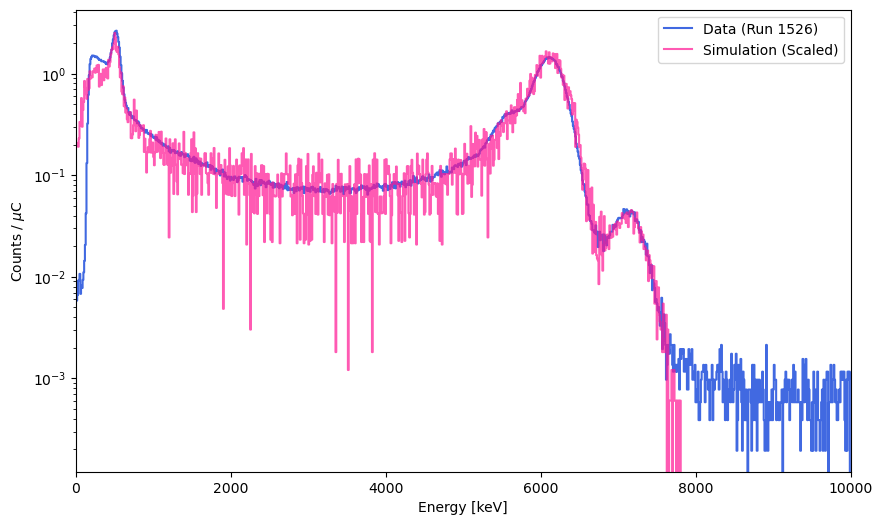

In [6]:
plt.figure(figsize=(10, 6))
plt.step(bin_edges[1:-1], hist_data[1:] / charge * 1.2, where='post', label='Data (Run 1526)', color='royalblue')
plt.step(bin_edges[1:-1], y * (hist_sim_2[1:] + hist_sim_4[1:] * 0.03) / 1e6, where='post', label='Simulation (Scaled)', alpha=0.7,color='deeppink')

plt.xlim(0, 10000)

plt.yscale('log')
plt.legend()

plt.xlabel("Energy [keV]")
plt.ylabel(r"Counts / $\mu$C")

plt.show()

Simulated counts in ROI: 4563.79
Simulated efficiency:  0.00456379


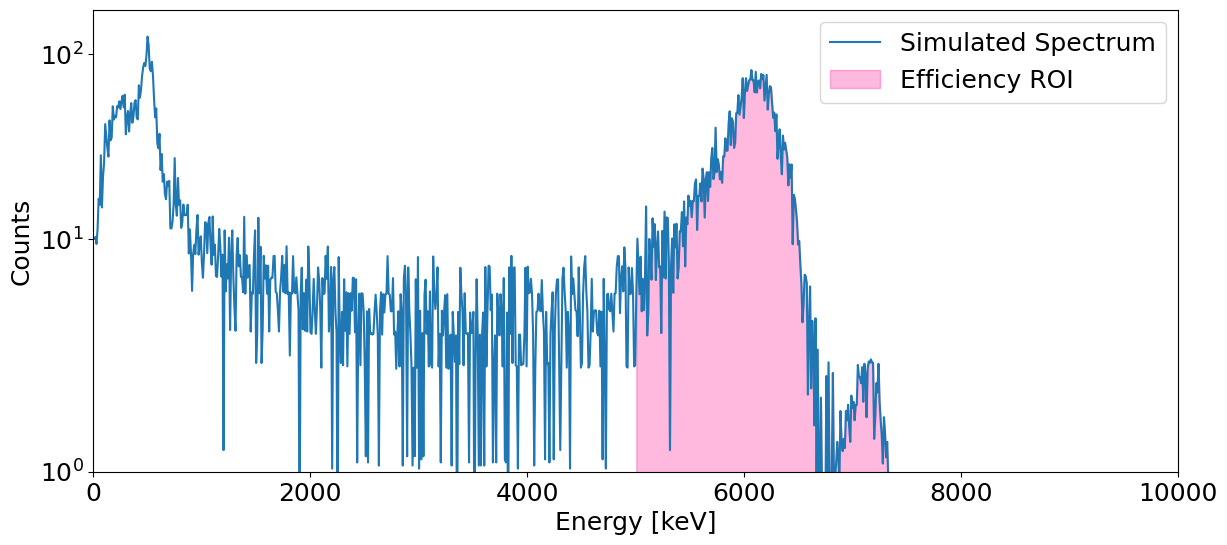

In [7]:
ROI_min, ROI_max = 5000, 7600
hist = hist_sim_2 + hist_sim_4 * 0.03

plt.matplotlib.rcParams.update({'font.size': 18})

# Compute the sum of events hist within ROI
ROI_hist = hist[(bin_edges[:-1] >= ROI_min) & (bin_edges[:-1] < ROI_max)].sum()
print("Simulated counts in ROI:", ROI_hist)
print("Simulated efficiency: ", ROI_hist / len(bgo_sum_2))

plt.figure(figsize=(14, 6))
plt.yscale("symlog")
plt.plot(bin_edges[1:-1], hist[1:], label='Simulated Spectrum')
plt.fill_between(bin_edges[:-1], 0, hist, where=( (bin_edges[:-1] >= ROI_min) & (bin_edges[:-1] < ROI_max) ), color='deeppink', alpha=0.3, label='Efficiency ROI')
plt.ylim(1,None)
plt.xlim(0, 10000)
plt.xlabel("Energy [keV]")
plt.ylabel("Counts")
plt.legend()
plt.show()

In [3]:
# Recover pa2
f1 = ROOT.TFile("/data0/biasissi/LUNA/19F+p_g+20Ne/Simulations/rootfiles/19F_pag_2.root")
t1 = f1.Get("Tree1")

data = {"BGO1": [], "BGO2": [], "BGO3": [], "BGO4": [], "BGO5": [], "BGO6": [] }
n_entries = t1.GetEntries()

for i in tqdm(range(n_entries)):
    t1.GetEntry(i)
    energies = t1.Edep
    for j in range(6):
        if energies[j] > 0:
            reso = get_resolution( energies[j], str(j+1) )
            energy = np.random.normal( energies[j], reso )
            data["BGO" + str(j+1)].append( energy )
        else:
            data["BGO" + str(j+1)].append( 0 )

# Create BGOsum
bgo_sum_2 = []
for i in range(len(data["BGO1"])):
    bgo_sum_2.append( data["BGO1"][i] + data["BGO2"][i] + data["BGO3"][i] + data["BGO4"][i] + data["BGO5"][i] + data["BGO6"][i] )

# Recover pa4
f1 = ROOT.TFile("/data0/biasissi/sim/rootfiles/19F_pag_4.root")
t1 = f1.Get("Tree1")

data = {"BGO1": [], "BGO2": [], "BGO3": [], "BGO4": [], "BGO5": [], "BGO6": [] }
n_entries = t1.GetEntries()

for i in tqdm(range(n_entries)):
    t1.GetEntry(i)
    energies = t1.Edep
    for j in range(6):
        if energies[j] > 0:
            reso = get_resolution( energies[j], str(j+1) )
            energy = np.random.normal( energies[j], reso )
            data["BGO" + str(j+1)].append( energy )
        else:
            data["BGO" + str(j+1)].append( 0 )

# Add to previous BGOsum
bgo_sum_4 = []
for i in range(len(data["BGO1"])):
    bgo_sum_4.append( data["BGO1"][i] + data["BGO2"][i] + data["BGO3"][i] + data["BGO4"][i] + data["BGO5"][i] + data["BGO6"][i] )

# Recover pa3
f1 = ROOT.TFile("/data0/biasissi/sim/rootfiles/19F_pag_3.root")
t1 = f1.Get("Tree1")

data = {"BGO1": [], "BGO2": [], "BGO3": [], "BGO4": [], "BGO5": [], "BGO6": [] }
n_entries = t1.GetEntries()

for i in tqdm(range(n_entries)):
    t1.GetEntry(i)
    energies = t1.Edep
    for j in range(6):
        if energies[j] > 0:
            reso = get_resolution( energies[j], str(j+1) )
            energy = np.random.normal( energies[j], reso )
            data["BGO" + str(j+1)].append( energy )
        else:
            data["BGO" + str(j+1)].append( 0 )

# Add to previous BGOsum
bgo_sum_3 = []
for i in range(len(data["BGO1"])):
    bgo_sum_3.append( data["BGO1"][i] + data["BGO2"][i] + data["BGO3"][i] + data["BGO4"][i] + data["BGO5"][i] + data["BGO6"][i] )


100%|██████████| 1000000/1000000 [00:08<00:00, 116881.09it/s]


In [4]:
charge = 7801  # Charge of run 1577

f1 = ROOT.TFile( "/data0/biasissi/LUNA/19F+p_g+20Ne/Data/PROCESSED/run1577.root" )
df = ROOT.RDataFrame( "coincidenceEvents", f1 )

# Convert to pandas DataFrame
df = df.AsNumpy( ["energyBGO1", "energyBGO2", "energyBGO3", "energyBGO4", "energyBGO5", "energyBGO6", "energySum", "isPulser"] )
df = pd.DataFrame( df )

# Mask the pulser events
df = df[ df["isPulser"] == 0 ]

In [5]:
bins = np.linspace(0, 10000, 1000)

# Calculate histograms
hist_data, bin_edges = np.histogram( df["energySum"], bins=bins )
hist_sim_2, bin_edges = np.histogram( bgo_sum_2, bins=bins )
hist_sim_3, bin_edges = np.histogram( bgo_sum_3, bins=bins )
hist_sim_4, bin_edges = np.histogram( bgo_sum_4, bins=bins )

In [6]:
omega_gamma = 0.014 # eV
energy = 214.8  # eV
stop = effective_stopping_Ta( energy, 3, 1 ) * 1e-15  # Convert to eV/(10^15 atoms/cm^2)

corr = 1.37 * 2 / np.pi

y = de_broglie( M0, M1, energy * 1e3 ) * omega_gamma / stop / q_c / 1e6 * corr

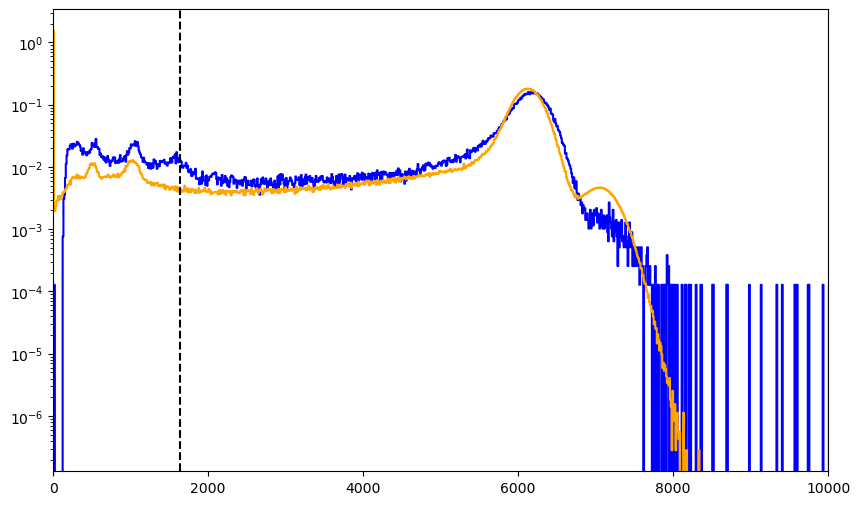

In [9]:
plt.figure(figsize=(10, 6))
plt.step(bin_edges[:-1] * 1.01, hist_data / charge, where='post', label='Data (Run 1526)', color='blue')
plt.step(bin_edges[:-1], y * (hist_sim_2/100*97 + hist_sim_4/100*2 + hist_sim_3/100*1) / 1e6, where='post', label='Simulation (Scaled)', color='orange')

plt.xlim(0, 10000)

plt.yscale('log')

plt.axvline(1633, color='black', linestyle='--')

plt.show()

Simulated counts in ROI: 695423.06
Simulated efficiency:  0.6954230600000001


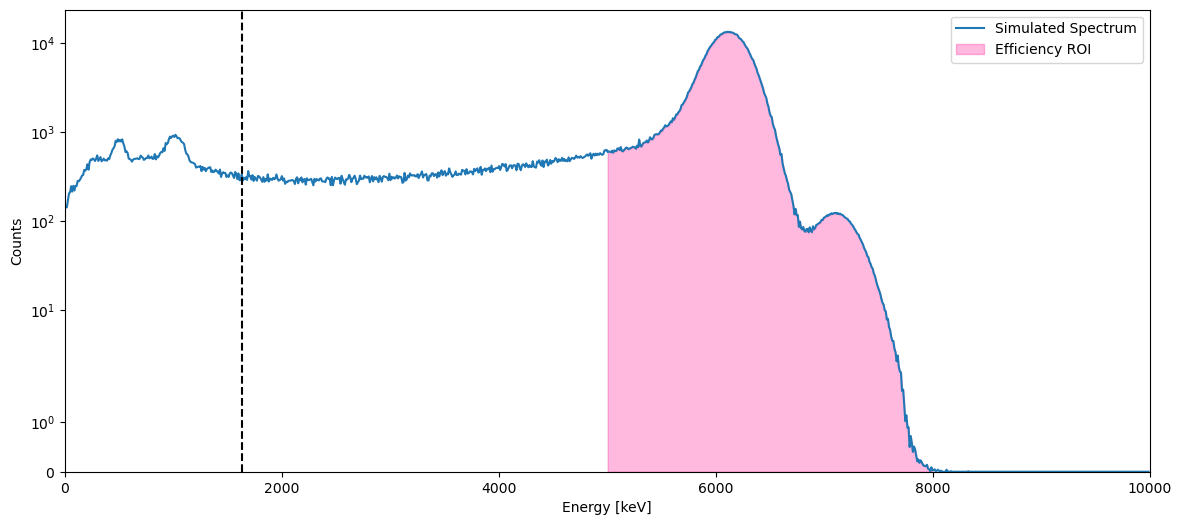

In [8]:
ROI_min, ROI_max = 5000, 8000
hist = hist_sim_2 + hist_sim_4 * 0.01

# Compute the sum of events hist within ROI
ROI_hist = hist[(bin_edges[:-1] >= ROI_min) & (bin_edges[:-1] < ROI_max)].sum()
print("Simulated counts in ROI:", ROI_hist)
print("Simulated efficiency: ", ROI_hist / len(bgo_sum_2))

plt.figure(figsize=(14, 6))
plt.yscale("symlog")
plt.plot(bin_edges[1:-1], hist[1:], label='Simulated Spectrum')
plt.fill_between(bin_edges[:-1], 0, hist, where=( (bin_edges[:-1] >= ROI_min) & (bin_edges[:-1] < ROI_max) ), color='deeppink', alpha=0.3, label='Efficiency ROI')
plt.ylim(0,None)
plt.xlim(0, 10000)
plt.xlabel("Energy [keV]")
plt.ylabel("Counts")
plt.legend()

plt.axvline(1633, color='black', linestyle='--')

plt.show()